In [1]:
import numpy as np
import gymnasium as gym
import torch
import os
import sys
import matplotlib.pylab as plt

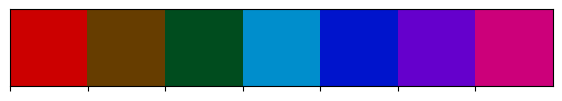

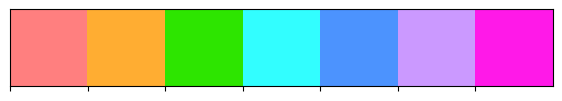

In [11]:
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.k_of_n_measure import get_obs_by_dryness_level, load_reward_models, get_rewards, load_replay_buffer
from src.policy_analysis import set_blind_colors
light_colors, dark_colors = set_blind_colors()

In [3]:
grid_size = [10, 10]
n_mdp_actions = 6
window_size = 3
dryness = 0.05
gamma = 0.99
bins = 25
device = "mps:0"

In [8]:
obs_dict = load_replay_buffer(grid_size, window_size, dryness, seed=4, device=device)
# obs_dict = load_replay_buffer(grid_size, window_size, dryness, seed=4, device="mps:0")

In [5]:
trained_models = load_reward_models(grid_size, window_size, dryness, n_r_models=500)

In [6]:
batch_size = 128
grid_size = [10, 10]
n_mdp_actions = 6
window_size = 11
dryness = 0.05
gamma = 0.99
q_lr = 0.0001
r_lr = 0.0001
bins = 25
center_indx = window_size // 2

device = "mps:0"
n_rows, n_colums = grid_size

main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/3_room/window_{}/eps_decay_1e-07/q_lr_{}/reward_lr_{}".format(n_rows, n_colums, dryness, window_size, q_lr, r_lr)

In [7]:
n_r_models = 500
trained_models = []
for r in range(n_r_models):
    trained_models.append(torch.load(main_dir + "/ensemble_reward_models/reward_model_{}".format(r), weights_only=False))

In [9]:
obs_0 = get_obs_by_dryness_level(window_size, obs_dict, dry_value=0.0)
obs_5 = get_obs_by_dryness_level(window_size, obs_dict, dry_value=0.5)
obs_1 = get_obs_by_dryness_level(window_size, obs_dict, dry_value=1.0)

In [10]:
rewards_0 = get_rewards(window_size, n_mdp_actions, trained_models, obs_0)
rewards_5 = get_rewards(window_size, n_mdp_actions, trained_models, obs_5)
rewards_1 = get_rewards(window_size, n_mdp_actions, trained_models, obs_1)

In [12]:
labels = {"plant": "Plant",
        "cactus": "Cactus",
        "diff_1": "[0, 0, 1]",
        "diff_2": "[0, 1, 0]",
        "diff_3": "[1, 0, 0]",
        "diff_4": "[1, 0, 1]",
        "diff_5": "[1, 1, 1]",
}

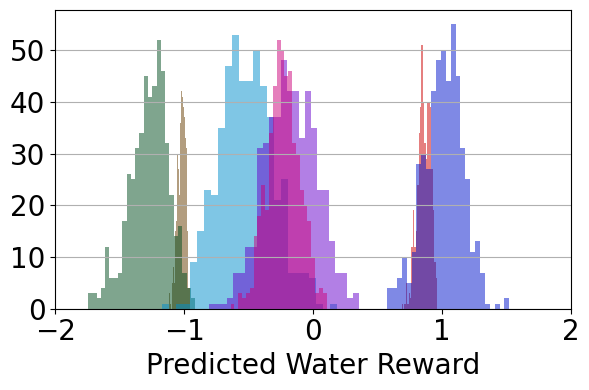

In [34]:
fig = plt.figure(figsize=(6, 4))
for i, l in enumerate(labels):
    plt.hist(rewards_5[l][1, :, 4], density=False, bins=bins, color=dark_colors[i], alpha=0.5, label=labels[l])

plt.xlabel("Predicted Water Reward", fontsize=20)
# plt.ylabel("Count", fontsize=20)
plt.grid(axis="y")
# plt.legend(fontsize=15)
plt.yticks(fontsize=20)
plt.xticks(np.arange(-2, 2.1, 1), fontsize=20)
# plt.ylim(0, 85)
# plt.xlim(-2, 2)
plt.tight_layout()
# plt.savefig(main_dir + "/reward_ensemble_precitions_plants_dry_0.5.pdf", dpi=300)

In [16]:
main_dir

'../general_models/Plants/reward_model/10_10_channel/dry_0.05/3_room/window_11/eps_decay_1e-07/q_lr_0.0001/reward_lr_0.0001'

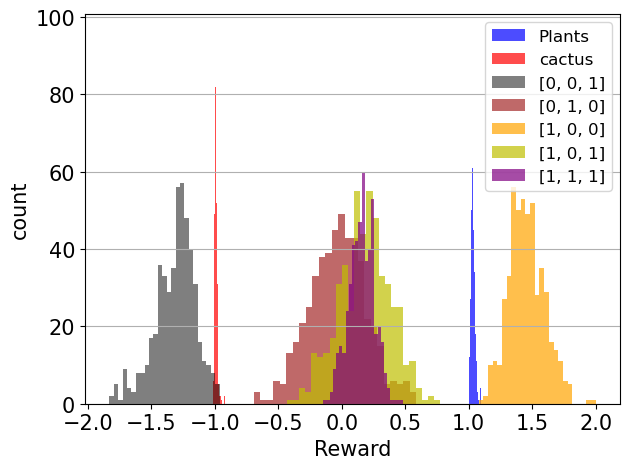

In [57]:
point = 2
plt.hist(rewards_1["plant"][point, :, 4], bins=bins, color="b", alpha=0.7, label="Plants")
plt.hist(rewards_1["cactus"][point, :, 4], bins=bins, color="r", alpha=0.7, label="cactus")
plt.hist(rewards_1["diff_1"][point, :, 4], bins=bins, color="black", alpha=0.5, label="[0, 0, 1]")
plt.hist(rewards_1["diff_2"][point, :, 4], bins=bins, color="brown", alpha=0.7, label="[0, 1, 0]")
plt.hist(rewards_1["diff_3"][point, :, 4], bins=bins, color="orange", alpha=0.7, label="[1, 0, 0]")
plt.hist(rewards_1["diff_4"][point, :, 4], bins=bins, color="y", alpha=0.7, label="[1, 0, 1]")
plt.hist(rewards_1["diff_5"][point, :, 4], bins=bins, color="purple", alpha=0.7, label="[1, 1, 1]")
plt.xlabel("Reward", fontsize=15)
plt.ylabel("count", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis="y")
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig(main_dir +"/hist_single_obs_level_{}_buffer_4.pdf".format(1.0), dpi=300)

##### load q_model

In [10]:
main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/room/window_{}/q_lr_{}/reward_lr_{}".format(
    grid_size[0], grid_size[0], dryness, window_size, 0.0001, 0.0001,
)

In [52]:
q_model  = torch.load(main_dir+ "/q_network_{}".format(1100))

In [53]:
key = "plant"
with torch.no_grad():
    mon_obs_0 = torch.zeros((obs_0[key].shape[0], 1), device=device)
    mon_obs_5 = torch.zeros((obs_5[key].shape[0], 1), device=device)
    mon_obs_1 = torch.zeros((obs_1[key].shape[0], 1), device=device)
    q_0 = torch.argmax(q_model[5:](torch.concat((q_model[:5](obs_0[key]), mon_obs_0), 1)), 1).cpu().numpy()
    q_5 = torch.argmax(q_model[5:](torch.concat((q_model[:5](obs_5[key]), mon_obs_5), 1)), 1).cpu().numpy()
    q_1 = torch.argmax(q_model[5:](torch.concat((q_model[:5](obs_1[key]), mon_obs_1), 1)), 1).cpu().numpy()

In [54]:
l = [len(np.where(q_1 == 4)[0]) / obs_1[key].shape[0], len(np.where(q_5 == 4)[0]) / obs_5[key].shape[0], len(np.where(q_0 == 4)[0]) / obs_0[key].shape[0]]
100 * np.round(l, 3)

array([99.9, 99.9,  0. ])